# Benchmark Analysis: CVDV vs Bosonic-Qiskit vs qcvdv

Load saved JSON results and generate comparison plots with log scale.

## 1. Import Required Libraries

In [18]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

## 2. Load JSON Result Files

In [19]:
# Set up paths
current_dir = Path('.')
results_dir = current_dir / 'results'
images_dir = current_dir / 'images'  # Go to qcvdv_analysis/images
images_dir.mkdir(parents=True, exist_ok=True)

json_file = results_dir / 'benchmark_results.json'

# Load results
if json_file.exists():
    with open(json_file, 'r') as f:
        results = json.load(f)
    print(f"✓ Loaded results from {json_file}")
    print(f"  Timestamp: {results.get('timestamp', 'N/A')}")
    print(f"  Config: {results.get('config', {})}")
else:
    print(f"✗ Results file not found: {json_file}")
    print(f"  Available files in {results_dir}:")
    for f in results_dir.glob('*'):
        print(f"    - {f.name}")

✓ Loaded results from results/benchmark_results.json
  Timestamp: 2026-05-14T19:50:04.669563
  Config: {'dv_qubits': 4, 'n_runs': 10, 'warmup': 2}


## 3. Parse and Structure Data

In [20]:
# Extract and organize benchmark data
cvdv_times = {}
cvdv_data = results.get('cvdv', {})
for cv_q_str, data in cvdv_data.items():
    cv_q = int(cv_q_str)
    cvdv_times[cv_q] = data.get('mean_ms', None)

bosonic_times = {}
bosonic_data = results.get('bosonic', {})
for cv_q_str, data in bosonic_data.items():
    cv_q = int(cv_q_str)
    bosonic_times[cv_q] = data.get('mean_ms', None)

qcvdv_times = {}
qcvdv_data = results.get('qcvdv', {})
for method, method_data in qcvdv_data.items():
    qcvdv_times[method] = {}
    for cv_q_str, data in method_data.items():
        cv_q = int(cv_q_str)
        qcvdv_times[method][cv_q] = data.get('mean_ms', None)

# Get union of all CV sizes for consistent ordering
all_cv_sizes = sorted(set(list(cvdv_times.keys()) + list(bosonic_times.keys())))
for method in qcvdv_times:
    all_cv_sizes = sorted(set(all_cv_sizes + list(qcvdv_times[method].keys())))

print(f"CV sizes available: {all_cv_sizes}")
print(f"CVDV sizes: {sorted(cvdv_times.keys())}")
print(f"Bosonic sizes: {sorted(bosonic_times.keys())}")
print(f"qcvdv methods: {list(qcvdv_times.keys())}")
for method in qcvdv_times:
    print(f"  {method}: {sorted(qcvdv_times[method].keys())}")

CV sizes available: [4, 5, 6, 7, 8, 9, 10, 11]
CVDV sizes: [4, 5, 6, 7, 8, 9, 10, 11]
Bosonic sizes: [4, 5, 6, 7, 8, 9]
qcvdv methods: ['dense_matrix_gpu', 'dense_matrix_gpuv1']
  dense_matrix_gpu: [4, 5, 6, 7, 8, 9, 10, 11]
  dense_matrix_gpuv1: [4, 5, 6, 7, 8, 9, 10, 11]


## 4. Generate and Save Plots as PDFs

### 4.1 Total Runtime Comparison (Log Scale)

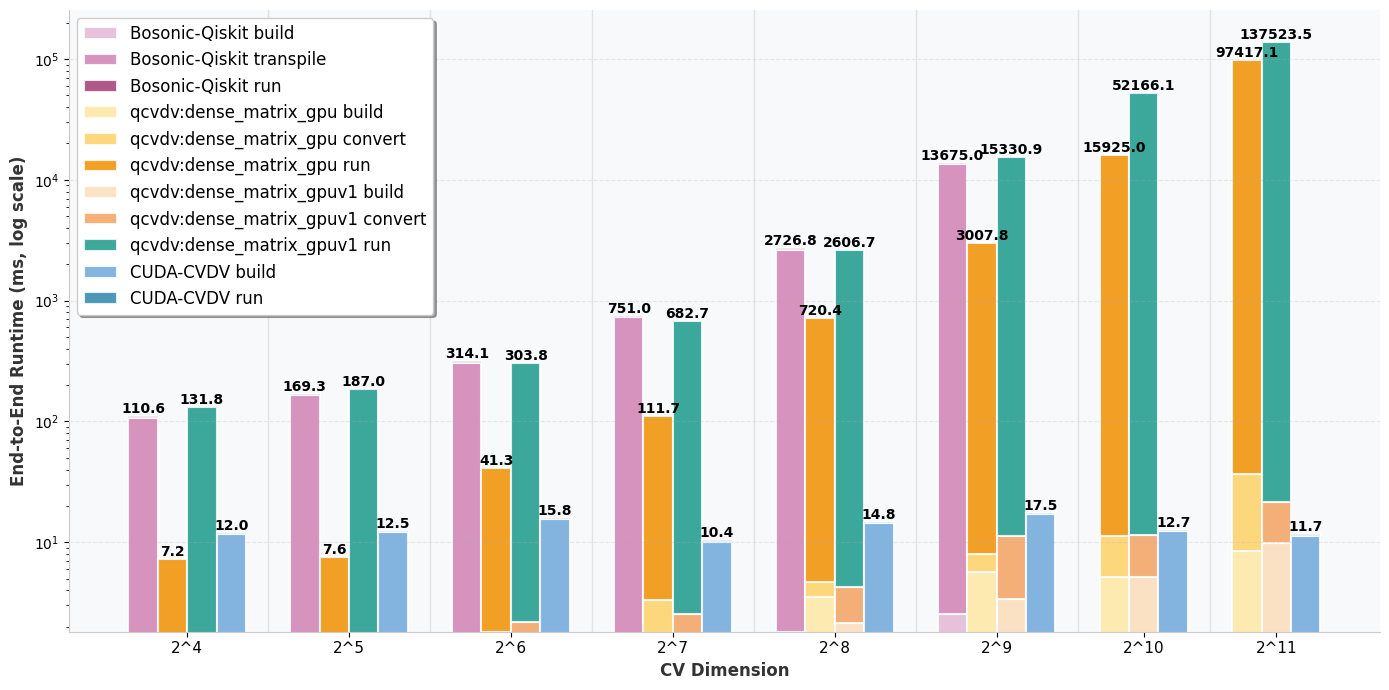

✓ Saved: images/comparison_log_scale.pdf


In [21]:
# Generate comparison plot (total runtime, log scale)
cvdv_build_c = '#6FA8DC'
cvdv_run_c = '#2E86AB'
bosonic_build_c = '#E5B8D5'
bosonic_transpile_c = '#D081B3'
bosonic_run_c = '#A23B72'
qcvdv_build_palette = ['#FFE8A3', '#FCDDBB', '#FFE3B3', '#F7E1A3', '#FCE5B3']
qcvdv_convert_palette = ['#FFD166', '#F4A261', '#F6BD60', '#E9C46A', '#FAC05E']
qcvdv_run_palette = ['#F18F01', '#1B998B', '#C73E1D', '#6A4C93', '#3A86FF']

width = 0.8
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

# Build grouped bar configurations by CV dimension
bar_configs = []
bar_segments = []
x_positions = []
group_centers = []
group_labels = []
group_boundaries = []
bar_spacing = 0.8
group_gap = 1.2
current_x = 0.0

for cv_q in sorted(all_cv_sizes):
    group_positions = []
    group_entries = []

    if str(cv_q) in bosonic_data and bosonic_data[str(cv_q)] is not None:
        bosonic_res = bosonic_data[str(cv_q)]
        build_ms = float(bosonic_res.get('build_mean_ms', 0.0))
        transpile_ms = float(bosonic_res.get('transpile_mean_ms', 0.0))
        run_ms = float(bosonic_res.get('run_mean_ms', 0.0))
        group_entries.append((
            'Bosonic',
            [
                ('Bosonic-Qiskit build', build_ms, bosonic_build_c),
                ('Bosonic-Qiskit transpile', transpile_ms, bosonic_transpile_c),
                ('Bosonic-Qiskit run', run_ms, bosonic_run_c)
            ]
        ))

    for method_idx, method in enumerate(sorted(qcvdv_times.keys())):
        if qcvdv_times[method].get(cv_q) is not None:
            qcvdv_res = qcvdv_data[method][str(cv_q)]
            build_c = qcvdv_build_palette[method_idx % len(qcvdv_build_palette)]
            convert_c = qcvdv_convert_palette[method_idx % len(qcvdv_convert_palette)]
            run_c = qcvdv_run_palette[method_idx % len(qcvdv_run_palette)]
            build_ms = float(qcvdv_res.get('build_mean_ms', 0.0))
            convert_ms = float(qcvdv_res.get('convert_mean_ms', 0.0))
            run_ms = float(qcvdv_res.get('run_mean_ms', qcvdv_times[method][cv_q]))
            group_entries.append((
                f'qcvdv:{method}',
                [
                    (f'qcvdv:{method} build', build_ms, build_c),
                    (f'qcvdv:{method} convert', convert_ms, convert_c),
                    (f'qcvdv:{method} run', run_ms, run_c)
                ]
            ))

    if str(cv_q) in cvdv_data and cvdv_data[str(cv_q)] is not None:
        cvdv_res = cvdv_data[str(cv_q)]
        build_ms = float(cvdv_res.get('build_mean_ms', 0.0))
        run_ms = float(cvdv_res.get('run_mean_ms', cvdv_times.get(cv_q, 0.0)))
        group_entries.append((
            'CVDV',
            [
                ('CUDA-CVDV build', build_ms, cvdv_build_c),
                ('CUDA-CVDV run', run_ms, cvdv_run_c)
            ]
        ))

    if not group_entries:
        continue

    for lib, segments in group_entries:
        bar_configs.append((lib, 2**cv_q))
        bar_segments.append(segments)
        x_positions.append(current_x)
        group_positions.append(current_x)
        current_x += bar_spacing

    group_centers.append(float(np.mean(group_positions)))
    group_labels.append(f'2^{cv_q}')
    group_boundaries.append(group_positions[-1] + (bar_spacing + group_gap) / 2)
    current_x += group_gap

# Plot bars
bars = []
for x_pos, segments in zip(x_positions, bar_segments):
    bottom = 0.0
    total_height = 0.0
    top_bar = None
    for segment_label, segment_value, segment_color in segments:
        top_bar = ax.bar(x_pos, segment_value, width, bottom=bottom, color=segment_color, alpha=0.85,
                         edgecolor='white', linewidth=1.5)[0]
        bottom += segment_value
        total_height += segment_value
    bars.append((top_bar, total_height))

# Add value labels on bars
for bar, total_height in bars:
    ax.text(bar.get_x() + bar.get_width()/2., total_height,
            f'{total_height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Create legend
from matplotlib.patches import Patch
legend_elements = []
legend_map = {}
for segments in bar_segments:
    for label, _, color in segments:
        if label not in legend_map:
            legend_map[label] = color
for label, color in legend_map.items():
    legend_elements.append(Patch(facecolor=color, alpha=0.85,
                                 edgecolor='white', linewidth=1.5, label=label))

# Styling
ax.set_ylabel('End-to-End Runtime (ms, log scale)', fontsize=12, fontweight='bold', color='#333')
ax.set_xlabel('CV Dimension', fontsize=12, fontweight='bold', color='#333')
# ax.set_title('End-to-End Runtime Comparison (Stacked Components)', fontsize=15, fontweight='bold', pad=20, color='#222')
ax.set_yscale('log')
ax.set_xticks(group_centers)

ax.set_xticklabels(group_labels, fontsize=11)
for boundary in group_boundaries[:-1]:
    ax.axvline(boundary, color='#DDDDDD', linewidth=1.0, alpha=0.8)
ax.legend(handles=legend_elements, fontsize=12, frameon=True, shadow=True, fancybox=True, loc='upper left')
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

# Save as PDF
pdf_file = images_dir / 'comparison_log_scale.pdf'
fig.savefig(pdf_file, format='pdf', bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {pdf_file}")
plt.close(fig)